In [29]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [30]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,18,male,33.770,1,no,southeast,1725.55230
3,28,male,33.000,3,no,southeast,4449.46200
4,33,male,22.705,0,no,northwest,21984.47061
...,...,...,...,...,...,...,...
1334,50,male,30.970,3,no,northwest,10600.54830
1335,18,female,31.920,0,no,northeast,2205.98080
1336,18,female,36.850,0,no,southeast,1629.83350
1337,21,female,25.800,0,no,southwest,2007.94500


EDA

In [31]:
df.shape


(1339, 7)

In [32]:
df.head

<bound method NDFrame.head of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      18    male  33.770         1     no  southeast   1725.55230
3      28    male  33.000         3     no  southeast   4449.46200
4      33    male  22.705         0     no  northwest  21984.47061
...   ...     ...     ...       ...    ...        ...          ...
1334   50    male  30.970         3     no  northwest  10600.54830
1335   18  female  31.920         0     no  northeast   2205.98080
1336   18  female  36.850         0     no  southeast   1629.83350
1337   21  female  25.800         0     no  southwest   2007.94500
1338   61  female  29.070         0    yes  northwest  29141.36030

[1339 rows x 7 columns]>

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1339 non-null   int64  
 1   sex       1339 non-null   object 
 2   bmi       1339 non-null   float64
 3   children  1339 non-null   int64  
 4   smoker    1339 non-null   object 
 5   region    1339 non-null   object 
 6   charges   1339 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.4+ KB


In [34]:
df.describe()

,age,bmi,children,charges
count,1339.000000,1339.000000,1339.000000,1339.000000
mean,39.191187,30.665717,1.094847,13261.800256
std,14.056661,6.096499,1.205045,12109.595636
min,18.000000,15.960000,0.000000,1121.873900
25%,26.500000,26.302500,0.000000,4729.002375
50%,39.000000,30.400000,1.000000,9377.904700
75%,51.000000,34.687500,2.000000,16622.107580
max,64.000000,53.130000,5.000000,63770.428010


In [35]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [36]:
numeric_columns= df[['age', 'bmi', 'children', 'charges']]

In [37]:
numeric_columns

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,18,33.770,1,1725.55230
3,28,33.000,3,4449.46200
4,33,22.705,0,21984.47061
...,...,...,...,...
1334,50,30.970,3,10600.54830
1335,18,31.920,0,2205.98080
1336,18,36.850,0,1629.83350
1337,21,25.800,0,2007.94500


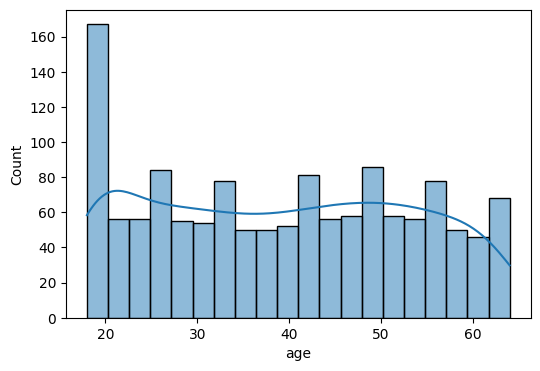

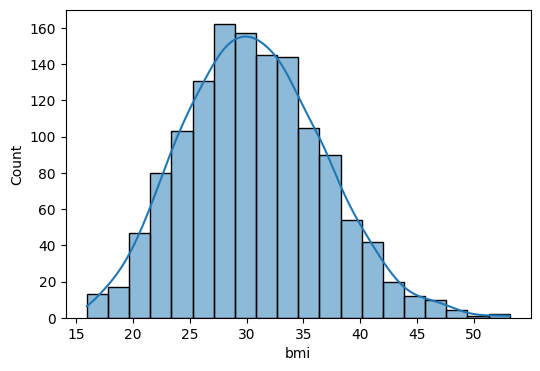

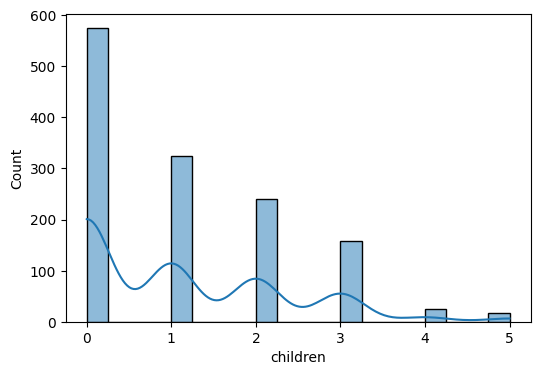

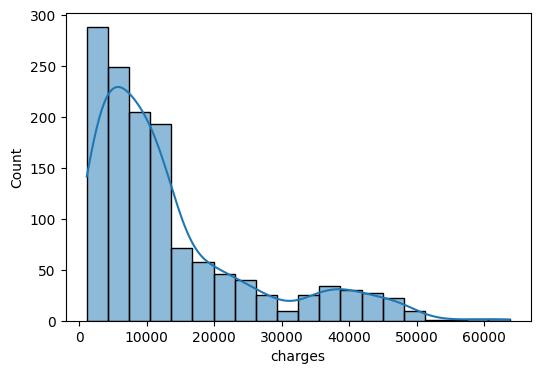

In [38]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde = True, bins=20)

<Axes: xlabel='children', ylabel='count'>

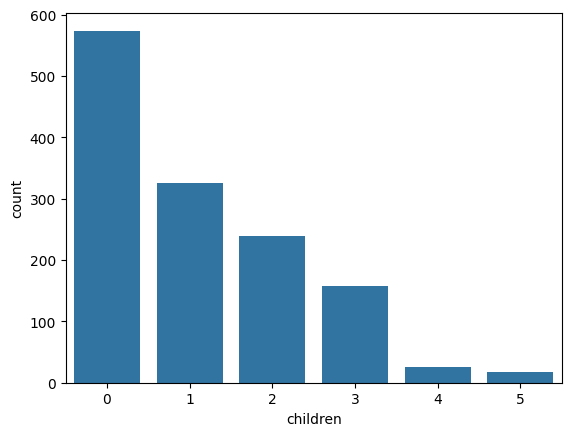

In [39]:
sns.countplot( x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

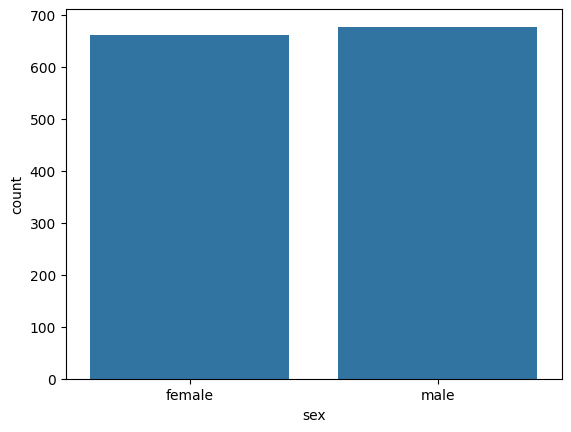

In [40]:
sns.countplot( x= df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

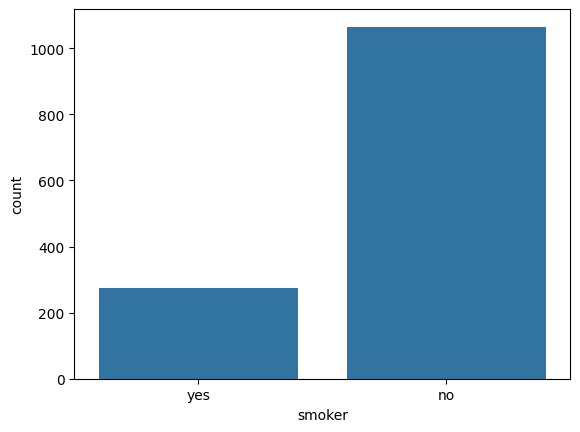

In [41]:
sns.countplot( x= df['smoker'])

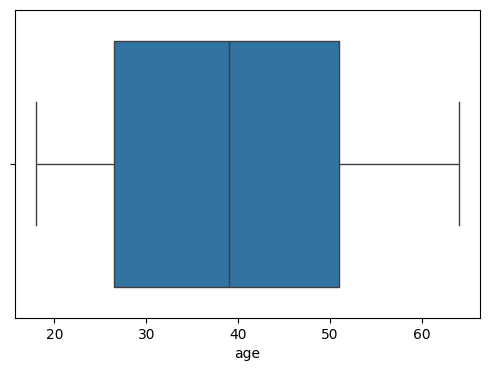

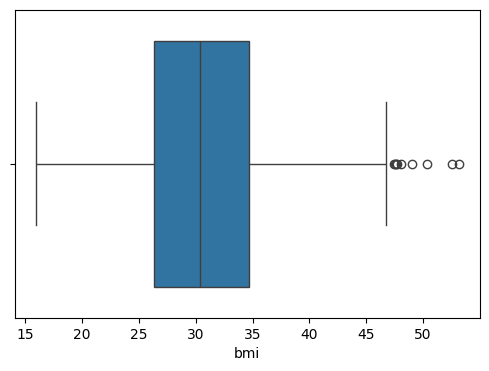

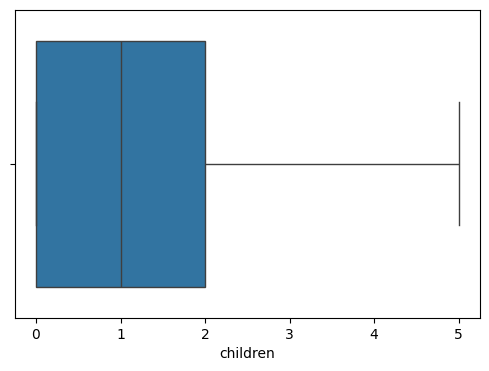

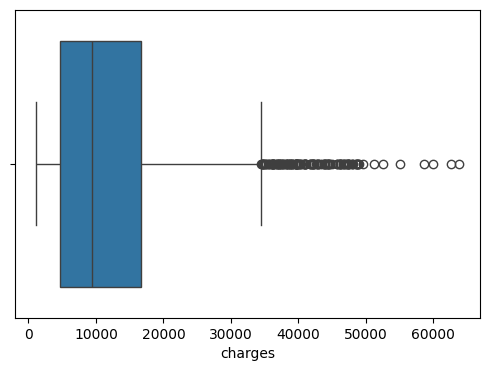

In [42]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x= df[col])

<Axes: >

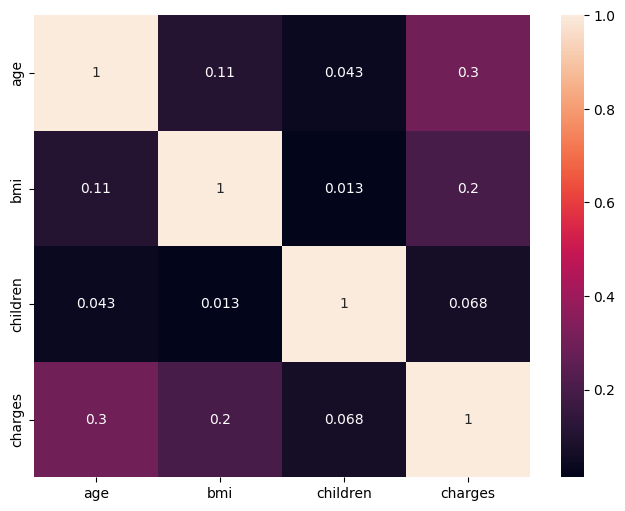

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot= True)

#datacleaning and data processing 

In [44]:
df_cleaned = df.copy()

In [45]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,18,male,33.770,1,no,southeast,1725.55230
3,28,male,33.000,3,no,southeast,4449.46200
4,33,male,22.705,0,no,northwest,21984.47061


In [46]:
df_cleaned.shape

(1339, 7)

In [47]:
df_cleaned.drop_duplicates(inplace= True)

In [48]:
df_cleaned.shape

(1337, 7)

In [49]:
df_cleaned['sex']= df_cleaned['sex'].map({"male": 0, "female": 1})

In [50]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
3,28,0,33.000,3,no,southeast,4449.46200
4,33,0,22.705,0,no,northwest,21984.47061
5,32,0,28.880,0,no,northwest,3866.85520


In [51]:
df_cleaned['smoker']= df_cleaned['smoker'].map({"yes": 1, "no":0})

In [52]:
df_cleaned.tail()

,age,sex,bmi,children,smoker,region,charges
1334,50,0,30.97,3,0,northwest,10600.5483
1335,18,1,31.92,0,0,northeast,2205.9808
1336,18,1,36.85,0,0,southeast,1629.8335
1337,21,1,25.80,0,0,southwest,2007.9450
1338,61,1,29.07,0,1,northwest,29141.3603


In [53]:
df_cleaned.rename(columns={
    'sex': 'isfemale', 'smoker': 'isSmoker'
},inplace=True)

In [54]:
df_cleaned

,age,isfemale,bmi,children,isSmoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
3,28,0,33.000,3,0,southeast,4449.46200
4,33,0,22.705,0,0,northwest,21984.47061
5,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1334,50,0,30.970,3,0,northwest,10600.54830
1335,18,1,31.920,0,0,northeast,2205.98080
1336,18,1,36.850,0,0,southeast,1629.83350
1337,21,1,25.800,0,0,southwest,2007.94500


In [55]:
df_cleaned = pd.get_dummies(df_cleaned, columns= ['region'])

In [56]:
df_cleaned

,age,isfemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
3,28,0,33.000,3,0,4449.46200,False,False,True,False
4,33,0,22.705,0,0,21984.47061,False,True,False,False
5,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1334,50,0,30.970,3,0,10600.54830,False,True,False,False
1335,18,1,31.920,0,0,2205.98080,True,False,False,False
1336,18,1,36.850,0,0,1629.83350,False,False,True,False
1337,21,1,25.800,0,0,2007.94500,False,False,False,True


In [57]:
df_cleaned = df_cleaned.astype(float)

In [58]:
df_cleaned

,age,isfemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19.0,1.0,27.900,0.0,1.0,16884.92400,0.0,0.0,0.0,1.0
1,18.0,0.0,33.770,1.0,0.0,1725.55230,0.0,0.0,1.0,0.0
3,28.0,0.0,33.000,3.0,0.0,4449.46200,0.0,0.0,1.0,0.0
4,33.0,0.0,22.705,0.0,0.0,21984.47061,0.0,1.0,0.0,0.0
5,32.0,0.0,28.880,0.0,0.0,3866.85520,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1334,50.0,0.0,30.970,3.0,0.0,10600.54830,0.0,1.0,0.0,0.0
1335,18.0,1.0,31.920,0.0,0.0,2205.98080,1.0,0.0,0.0,0.0
1336,18.0,1.0,36.850,0.0,0.0,1629.83350,0.0,0.0,1.0,0.0
1337,21.0,1.0,25.800,0.0,0.0,2007.94500,0.0,0.0,0.0,1.0


#Feature Engineering and Extreaction

In [59]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0, 18.5, 24.9, 29.9, float('inf')],
    labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
    
)

In [60]:
df_cleaned

,age,isfemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19.0,1.0,27.900,0.0,1.0,16884.92400,0.0,0.0,0.0,1.0,Overweight
1,18.0,0.0,33.770,1.0,0.0,1725.55230,0.0,0.0,1.0,0.0,Obese
3,28.0,0.0,33.000,3.0,0.0,4449.46200,0.0,0.0,1.0,0.0,Obese
4,33.0,0.0,22.705,0.0,0.0,21984.47061,0.0,1.0,0.0,0.0,Normal
5,32.0,0.0,28.880,0.0,0.0,3866.85520,0.0,1.0,0.0,0.0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1334,50.0,0.0,30.970,3.0,0.0,10600.54830,0.0,1.0,0.0,0.0,Obese
1335,18.0,1.0,31.920,0.0,0.0,2205.98080,1.0,0.0,0.0,0.0,Obese
1336,18.0,1.0,36.850,0.0,0.0,1629.83350,0.0,0.0,1.0,0.0,Obese
1337,21.0,1.0,25.800,0.0,0.0,2007.94500,0.0,0.0,0.0,1.0,Overweight


In [61]:
df_cleaned = pd.get_dummies(df_cleaned, columns= ['bmi_category'])

In [62]:
df_cleaned = df_cleaned.astype(int)
df_cleaned

,age,isfemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
3,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
4,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
5,32,0,28,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334,50,0,30,3,0,10600,0,1,0,0,0,0,0,1
1335,18,1,31,0,0,2205,1,0,0,0,0,0,0,1
1336,18,1,36,0,0,1629,0,0,1,0,0,0,0,1
1337,21,1,25,0,0,2007,0,0,0,1,0,0,1,0


In [63]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

df_cleaned[cols]= scaler.fit_transform(df_cleaned[cols])

In [64]:
df_cleaned.head()

,age,isfemale,bmi,children,isSmoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,0,1,0,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,0,1,0,0,0,0,1
3,-0.799350,0,0.462463,1.580143,0,4449,0,0,1,0,0,0,0,1
4,-0.443201,0,-1.334960,-0.909234,0,21984,0,1,0,0,0,1,0,0
5,-0.514431,0,-0.354547,-0.909234,0,3866,0,1,0,0,0,0,1,0


In [65]:
df_cleaned.columns

Index(['age', 'isfemale', 'bmi', 'children', 'isSmoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [66]:
from scipy.stats import pearsonr

selected_features = [
        'age', 'isfemale', 'bmi', 'children', 'isSmoker', 'charges',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese']


In [67]:
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(
    list(correlations.items()),
    columns=['Feature', 'Pearson Correlation']
)

correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
5,charges,1.000000
4,isSmoker,0.787234
0,age,0.298309
13,bmi_category_Obese,0.197660
2,bmi,0.196236
8,region_southeast,0.073577
3,children,0.067390
6,region_northeast,0.005946
7,region_northwest,-0.038695
9,region_southwest,-0.043637


In [68]:
cat_features = [
   'isfemale', 'isSmoker',
       'region_northeast', 'region_northwest', 'region_southeast',
       'region_southwest', 'bmi_category_Underweight', 'bmi_category_Normal',
       'bmi_category_Overweight', 'bmi_category_Obese']


In [69]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

In [70]:
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
isSmoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
isfemale,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obese,7.654464,0.05372,Accept Null (Drop Feature)
region_northeast,6.438442,0.092122,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Underweight,4.384749,0.222804,Accept Null (Drop Feature)
bmi_category_Normal,4.263673,0.234364,Accept Null (Drop Feature)
bmi_category_Overweight,4.201575,0.240504,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [71]:
final_df = df_cleaned[['age', 'isfemale', 'bmi', 'children', 'isSmoker', 'charges', 'region_southeast' ]]

In [72]:
final_df

,age,isfemale,bmi,children,isSmoker,charges,region_southeast
0,-1.440418,1,-0.517949,-0.909234,1,16884,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1
3,-0.799350,0,0.462463,1.580143,0,4449,1
4,-0.443201,0,-1.334960,-0.909234,0,21984,0
5,-0.514431,0,-0.354547,-0.909234,0,3866,0
...,...,...,...,...,...,...,...
1334,0.767704,0,-0.027743,1.580143,0,10600,0
1335,-1.511647,1,0.135659,-0.909234,0,2205,0
1336,-1.511647,1,0.952670,-0.909234,0,1629,1
1337,-1.297958,1,-0.844753,-0.909234,0,2007,0


#Trained Test Split

In [73]:
from sklearn.model_selection import train_test_split

In [75]:
X = final_df.drop('charges', axis =1)
y = final_df['charges']

In [77]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [78]:
Y_test

901      8688
1065     5708
1257    11436
299     38746
238      4463
        ...  
535     13831
543     13887
761      3925
1285    47403
1286     8534
Name: charges, Length: 268, dtype: int64

In [82]:
from sklearn.linear_model import LinearRegression

In [83]:
model = LinearRegression()

In [85]:
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [87]:
y_pred = model.predict(X_test)

In [90]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, y_pred)
r2

0.8053741941169437

In [92]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.8009000376598618